# Homework 2 Solution

In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_palette("husl")
plt.rcParams.update(
    {
        "figure.facecolor": "#111111",
        "axes.facecolor": "#111111",
        "axes.edgecolor": "#aaaaaa",
        "text.color": "#ffffff",
        "xtick.color": "#aaaaaa",
        "ytick.color": "#aaaaaa",
    }
)

os.makedirs("./figures", exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Problem 1

### 1.1

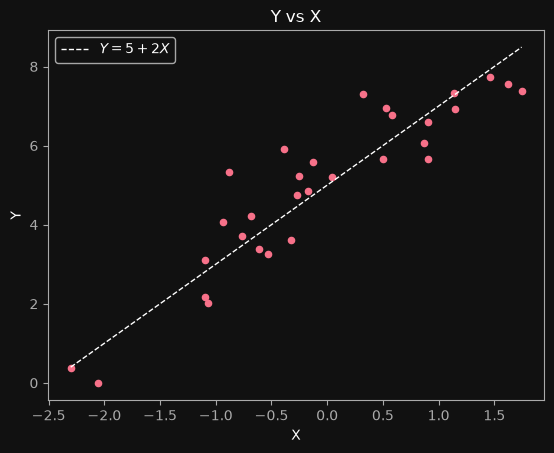

In [3]:
np.random.seed(1)

n = 30
X = np.random.normal(0, 1, n)
eps = np.random.normal(0, 1, n)
Y = 5 + 2 * X + eps
data = pd.DataFrame({"X": X, "Y": Y})

ax = data.plot.scatter(x="X", y="Y", title="Y vs X")
ax.plot(np.sort(X), 5 + 2 * np.sort(X), color="white", ls="--", lw=1, label="$Y = 5 + 2X$")
ax.legend()
ax.figure.savefig("./figures/problem1_scatter.png", dpi=300, bbox_inches="tight")

### 1.2

In [4]:
model = sm.OLS(data["Y"], sm.add_constant(data["X"])).fit()
print(model.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        Y         & \textbf{  R-squared:         } &     0.840   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &     0.834   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &     146.7   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):} &  1.20e-12   \\
\textbf{Time:}             &     09:16:31     & \textbf{  Log-Likelihood:    } &   -36.484   \\
\textbf{No. Observations:} &          30      & \textbf{  AIC:               } &     76.97   \\
\textbf{Df Residuals:}     &          28      & \textbf{  BIC:               } &     79.77   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
               & \textbf{coef} & \textb

### 1.3

Written answer only; see the write-up.

### 1.4

In [5]:
data_mod = data.copy()
data_mod.iloc[-1] = (4.0, -5.0)

model_mod = sm.OLS(data_mod["Y"], sm.add_constant(data_mod["X"])).fit()
print(model_mod.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        Y         & \textbf{  R-squared:         } &     0.027   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared:    } &    -0.008   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       } &    0.7723   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):} &    0.387    \\
\textbf{Time:}             &     09:16:31     & \textbf{  Log-Likelihood:    } &   -71.713   \\
\textbf{No. Observations:} &          30      & \textbf{  AIC:               } &     147.4   \\
\textbf{Df Residuals:}     &          28      & \textbf{  BIC:               } &     150.2   \\
\textbf{Df Model:}         &           1      & \textbf{                     } &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     } &             \\
\bottomrule
\end{tabular}
\begin{tabular}{lcccccc}
               & \textbf{coef} & \textb

### 1.5

Written answer only; see the write-up.

### 1.6

Cook's D for observation 30: 7.4530
largest of the other 29:     0.1676


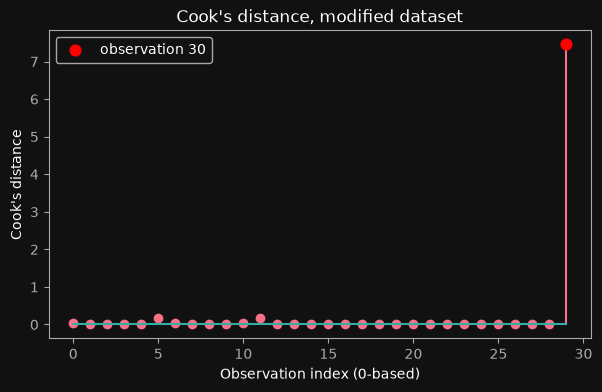

In [6]:
influence = model_mod.get_influence()
cooks_d = pd.Series(influence.cooks_distance[0])

fig, ax = plt.subplots(figsize=(7, 4))
ax.stem(cooks_d.index, cooks_d.to_numpy())
ax.scatter([29], [cooks_d.iloc[-1]], color="red", zorder=3, s=60, label="observation 30")
ax.set_xlabel("Observation index (0-based)")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's distance, modified dataset")
ax.legend()
fig.savefig("./figures/problem1_cooks_distance.png", dpi=300, bbox_inches="tight")

print(f"Cook's D for observation 30: {cooks_d.iloc[-1]:.4f}")
print(f"largest of the other 29:     {cooks_d.iloc[:-1].max():.4f}")

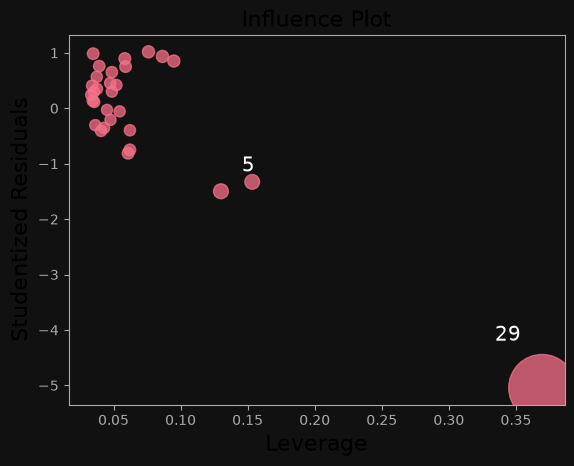

In [7]:
fig = influence.plot_influence()
fig.savefig("./figures/problem1_influence_plot.png", dpi=300, bbox_inches="tight")

### 1.7

In [8]:
rows = []
for px, py in [(4.0, -5.0), (0.0, -5.0)]:
    d = data.copy()
    d.iloc[-1] = (px, py)
    m = sm.OLS(d["Y"], sm.add_constant(d["X"])).fit()
    h = m.get_influence().hat_matrix_diag
    rows.append(
        {
            "point": f"({px:.0f}, {py:.0f})",
            "leverage_h30": h[-1],
            "cooks_d30": m.get_influence().cooks_distance[0][-1],
            "beta_1": m.params["X"],
        }
    )
leverage = pd.DataFrame(rows).set_index("point")
print(f"1/n = {1 / n:.4f}")
print(leverage.to_latex(float_format="{:0.4f}".format))

1/n = 0.0333
\begin{tabular}{lrrr}
\toprule
 & leverage_h30 & cooks_d30 & beta_1 \\
point &  &  &  \\
\midrule
(4, -5) & 0.3695 & 7.4530 & 0.3533 \\
(0, -5) & 0.0335 & 0.4059 & 1.8077 \\
\bottomrule
\end{tabular}



## Problem 2

### 2.1

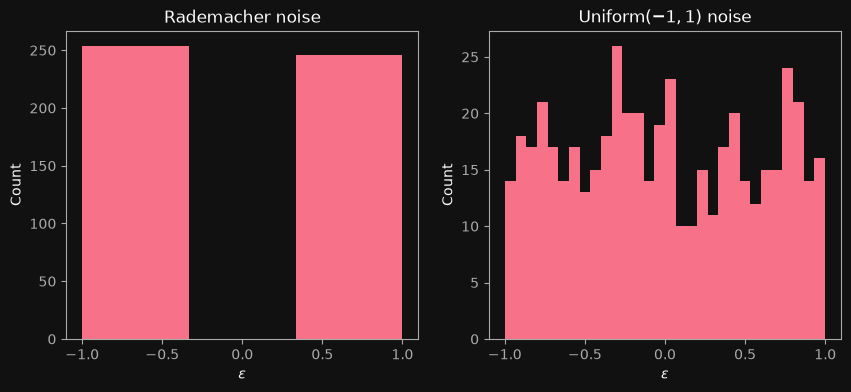

In [9]:
np.random.seed(0)

n = 500
eps_rademacher = 2 * np.random.binomial(1, 0.5, n) - 1
eps_uniform = 2 * np.random.rand(n) - 1

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(eps_rademacher, bins=3)
ax[0].set_title("Rademacher noise")
ax[1].hist(eps_uniform, bins=30)
ax[1].set_title("Uniform$(-1, 1)$ noise")
for a in ax:
    a.set_xlabel("$\\epsilon$")
    a.set_ylabel("Count")
fig.savefig("./figures/problem2_error_histograms.png", dpi=300, bbox_inches="tight")

### 2.2

In [10]:
res_beta = {}
x = np.random.rand(1000)  # fixed for the whole problem; only the noise is resampled
for n in [10, 100, 1000]:
    x_n = x[:n]
    draws = {"beta1": [], "beta2": []}
    for _ in range(1000):
        eps1 = 2 * np.random.binomial(1, 0.5, n) - 1
        eps2 = 2 * np.random.rand(n) - 1
        draws["beta1"].append(sm.OLS(2 * x_n + eps1, x_n).fit().params[-1])
        draws["beta2"].append(sm.OLS(2 * x_n + eps2, x_n).fit().params[-1])
    res_beta[n] = pd.DataFrame(draws)

### 2.3

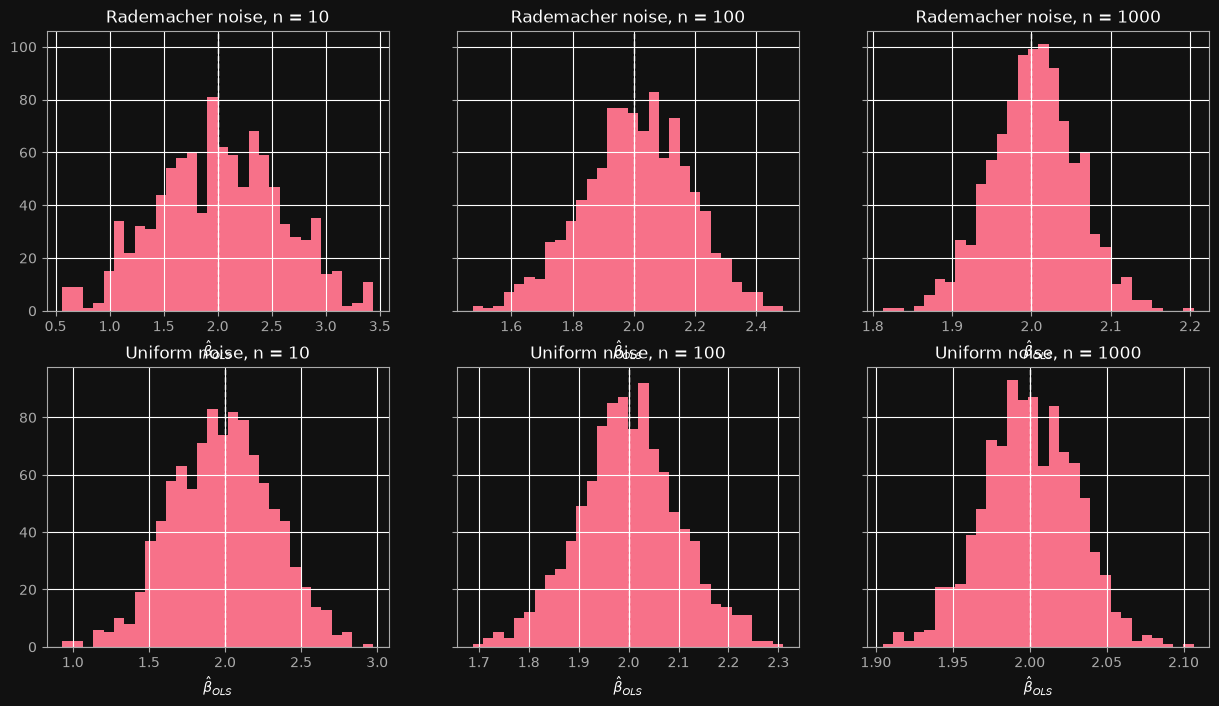

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharey="row")
for i, n in enumerate(res_beta):
    for row, (col, label) in enumerate([("beta1", "Rademacher"), ("beta2", "Uniform")]):
        res_beta[n][col].hist(bins=30, ax=ax[row, i])
        ax[row, i].axvline(2, color="white", ls="--", lw=1)
        ax[row, i].set_title(f"{label} noise, n = {n}")
        ax[row, i].set_xlabel(r"$\hat{\beta}_{OLS}$")
fig.savefig("./figures/problem2_beta_histograms.png", dpi=300, bbox_inches="tight")

In [12]:
shapiro = {"shapiro_stat": {}, "shapiro_p": {}}
for n in res_beta:
    for i in [1, 2]:
        stat, p = stats.shapiro(res_beta[n][f"beta{i}"])
        shapiro["shapiro_stat"][f"{n}_beta{i}"] = stat
        shapiro["shapiro_p"][f"{n}_beta{i}"] = p
print(pd.DataFrame(shapiro).T.to_latex(escape=True, float_format="{:0.4f}".format))

\begin{tabular}{lrrrrrr}
\toprule
 & 10\_beta1 & 10\_beta2 & 100\_beta1 & 100\_beta2 & 1000\_beta1 & 1000\_beta2 \\
\midrule
shapiro\_stat & 0.9953 & 0.9983 & 0.9976 & 0.9983 & 0.9991 & 0.9988 \\
shapiro\_p & 0.0038 & 0.4183 & 0.1475 & 0.4453 & 0.9025 & 0.7548 \\
\bottomrule
\end{tabular}



## Problem 3

### 3.1

The true model has no intercept, so every fit below is through the origin.

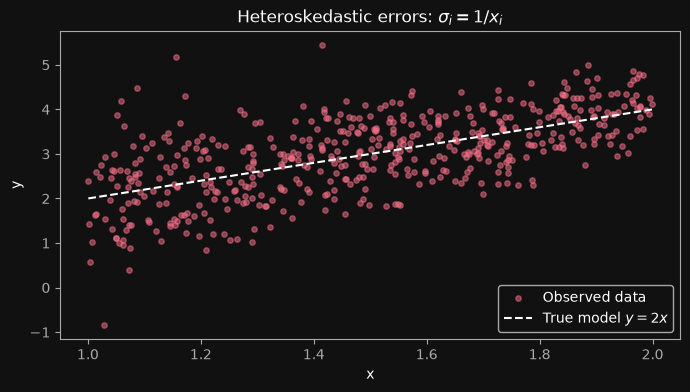

In [13]:
np.random.seed(3)

n = 500
x = np.random.uniform(1, 2, n)
sigma = 1 / x
eps = np.random.normal(0, sigma)
y = 2 * x + eps

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y, alpha=0.5, s=15, label="Observed data")
ax.plot(np.sort(x), 2 * np.sort(x), color="white", ls="--", lw=1.5, label="True model $y = 2x$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Heteroskedastic errors: $\\sigma_i = 1 / x_i$")
ax.legend()
fig.savefig("./figures/problem3_scatter.png", dpi=300, bbox_inches="tight")

### 3.2

In [14]:
model_ols = sm.OLS(y, x).fit()
print(model_ols.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared (uncentered):}      &     0.950   \\
\textbf{Model:}            &       OLS        & \textbf{  Adj. R-squared (uncentered):} &     0.950   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       }          &     9524.   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):}          &     0.00    \\
\textbf{Time:}             &     09:16:32     & \textbf{  Log-Likelihood:    }          &   -530.72   \\
\textbf{No. Observations:} &         500      & \textbf{  AIC:               }          &     1063.   \\
\textbf{Df Residuals:}     &         499      & \textbf{  BIC:               }          &     1068.   \\
\textbf{Df Model:}         &           1      & \textbf{                     }          &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     }          &             \\
\bottomru

### 3.3

In [15]:
model_robust = sm.OLS(y, x).fit(cov_type="HC3")

comparison = pd.DataFrame(
    {
        "beta_hat": [model_ols.params[0], model_robust.params[0]],
        "std_err": [model_ols.bse[0], model_robust.bse[0]],
        "ci_lower": [model_ols.conf_int()[0][0], model_robust.conf_int()[0][0]],
        "ci_upper": [model_ols.conf_int()[0][1], model_robust.conf_int()[0][1]],
    },
    index=["OLS (conventional)", "OLS (HC3 robust)"],
)
print(comparison.to_latex(float_format="{:0.5f}".format))
print(f"ratio of standard errors: {model_ols.bse[0] / model_robust.bse[0]:.4f}")
print(f"theory, sqrt(E[1/x^2] E[x^2]) = sqrt(7/6) = {np.sqrt(7 / 6):.4f}")

\begin{tabular}{lrrrr}
\toprule
 & beta_hat & std_err & ci_lower & ci_upper \\
\midrule
OLS (conventional) & 2.00870 & 0.02058 & 1.96826 & 2.04914 \\
OLS (HC3 robust) & 2.00870 & 0.01908 & 1.97131 & 2.04610 \\
\bottomrule
\end{tabular}

ratio of standard errors: 1.0788
theory, sqrt(E[1/x^2] E[x^2]) = sqrt(7/6) = 1.0801


### 3.4

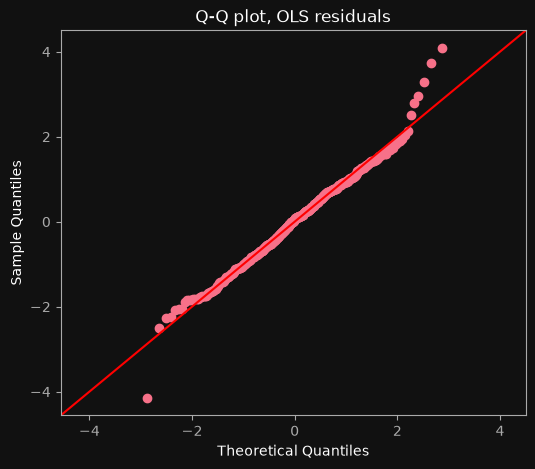

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
sm.qqplot(model_ols.resid, line="45", fit=True, ax=ax)
ax.set_title("Q-Q plot, OLS residuals")
fig.savefig("./figures/problem3_OLS_qq_plot.png", dpi=300, bbox_inches="tight")

### 3.5

In [17]:
model_wls = sm.WLS(y, x, weights=x**2).fit()
print(model_wls.summary().as_latex())

\begin{center}
\begin{tabular}{lclc}
\toprule
\textbf{Dep. Variable:}    &        y         & \textbf{  R-squared (uncentered):}      &     0.962   \\
\textbf{Model:}            &       WLS        & \textbf{  Adj. R-squared (uncentered):} &     0.962   \\
\textbf{Method:}           &  Least Squares   & \textbf{  F-statistic:       }          & 1.262e+04   \\
\textbf{Date:}             & Sat, 19 Sep 2026 & \textbf{  Prob (F-statistic):}          &     0.00    \\
\textbf{Time:}             &     09:16:33     & \textbf{  Log-Likelihood:    }          &   -510.11   \\
\textbf{No. Observations:} &         500      & \textbf{  AIC:               }          &     1022.   \\
\textbf{Df Residuals:}     &         499      & \textbf{  BIC:               }          &     1026.   \\
\textbf{Df Model:}         &           1      & \textbf{                     }          &             \\
\textbf{Covariance Type:}  &    nonrobust     & \textbf{                     }          &             \\
\bottomru

### 3.6

\begin{tabular}{lrrr}
\toprule
 & std_dev & shapiro_p & corr_abs_resid_x \\
\midrule
OLS residuals & 0.6994 & 0.0011 & -0.2577 \\
Weighted (WLS) residuals & 0.9852 & 0.1190 & -0.0024 \\
\bottomrule
\end{tabular}



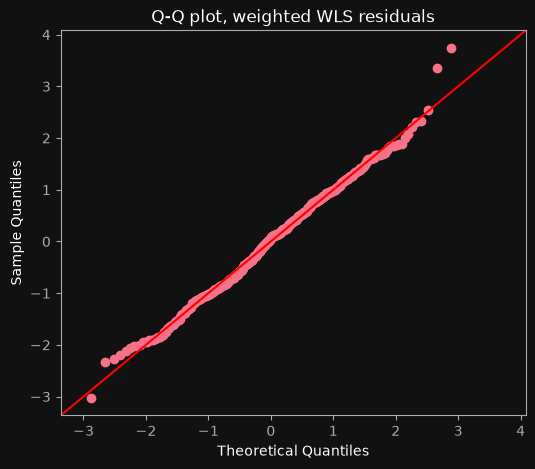

In [18]:
weighted_residuals = model_wls.wresid  # sqrt(w_i) * (y_i - x_i beta_hat)

fig, ax = plt.subplots(figsize=(6, 5))
sm.qqplot(weighted_residuals, line="45", fit=True, ax=ax)
ax.set_title("Q-Q plot, weighted WLS residuals")
fig.savefig("./figures/problem3_WLS_qq_plot.png", dpi=300, bbox_inches="tight")

diagnostics = pd.DataFrame(
    {
        "std_dev": [model_ols.resid.std(), weighted_residuals.std()],
        "shapiro_p": [
            stats.shapiro(model_ols.resid).pvalue,
            stats.shapiro(weighted_residuals).pvalue,
        ],
        "corr_abs_resid_x": [
            np.corrcoef(np.abs(model_ols.resid), x)[0, 1],
            np.corrcoef(np.abs(weighted_residuals), x)[0, 1],
        ],
    },
    index=["OLS residuals", "Weighted (WLS) residuals"],
)
print(diagnostics.to_latex(float_format="{:0.4f}".format))